# 📊 EDA — Empleo por Tipo de Contrato
**Fuente:** `e_tipo_contrato.csv`  
**Descripción:** Empleo dependiente privado mensual en Lima Metropolitana según tipo de contrato: Indeterminado (plazo indefinido), A Plazo Fijo y No Especificado. Período 2015–2025.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({'figure.dpi': 130})
sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'indeterminado': '#16a085', 'plazo_fijo': '#d35400', 'no_esp': '#7f8c8d'}
MES_ORDEN = {'ENE.':1,'FEB.':2,'MAR.':3,'ABR.':4,'MAY.':5,'JUN.':6,
             'JUL.':7,'AGO.':8,'SET.':9,'OCT.':10,'NOV.':11,'DIC.':12}
MESES_ETQ = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Set','Oct','Nov','Dic']
print('OK ✓')

OK ✓


## 1. Carga y Limpieza

In [2]:
df = pd.read_csv('e_tipo_contrato.csv', sep=';', encoding='utf-8', on_bad_lines='skip')
df.columns = df.columns.str.replace('\n', ' ', regex=False).str.strip()
df.columns = ['anio','mes','indeterminado','plazo_fijo','no_especificado']

for col in ['indeterminado','plazo_fijo','no_especificado']:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=['indeterminado'], inplace=True)
df['anio'] = df['anio'].astype(int)
df['mes_num'] = df['mes'].map(MES_ORDEN)
df['fecha'] = pd.to_datetime(df['anio'].astype(str) + '-' + df['mes_num'].astype(str).str.zfill(2), format='%Y-%m')
df.sort_values('fecha', inplace=True)
df.reset_index(drop=True, inplace=True)
df['total'] = df['indeterminado'] + df['plazo_fijo'] + df['no_especificado']

print(f'Shape: {df.shape}')
df.head()

Shape: (128, 8)


,anio,mes,indeterminado,plazo_fijo,no_especificado,mes_num,fecha,total
0,2015,ENE.,1149880,1968338,12137,1,2015-01-01,3130355
1,2015,FEB.,1153772,1952830,11909,2,2015-02-01,3118511
2,2015,MAR.,1165441,1994194,10420,3,2015-03-01,3170055
3,2015,ABR.,1171257,1989684,50842,4,2015-04-01,3211783
4,2015,MAY.,1169559,1995609,54058,5,2015-05-01,3219226


## 2. Estadísticas Descriptivas

In [3]:
desc = df[['indeterminado','plazo_fijo','no_especificado','total']].describe().round(0)
desc.index = ['Conteo','Media','Desv. Est.','Mín','Q25','Mediana','Q75','Máx']
desc

,indeterminado,plazo_fijo,no_especificado,total
Conteo,128.0,128.0,128.0,128.0
Media,1180957.0,2430144.0,27852.0,3638953.0
Desv. Est.,45049.0,347812.0,35252.0,369698.0
Mín,1035332.0,1756094.0,10420.0,2810882.0
Q25,1161828.0,2140883.0,13734.0,3351678.0
Mediana,1189502.0,2360561.0,18500.0,3556945.0
Q75,1209968.0,2699435.0,25520.0,3919678.0
Máx,1256113.0,3192778.0,253961.0,4454406.0


In [4]:
df2 = df.copy()
df2['total_2cat'] = df2['indeterminado'] + df2['plazo_fijo']
df2['pct_indet'] = df2['indeterminado'] / df2['total_2cat'] * 100
df2['pct_fijo'] = df2['plazo_fijo'] / df2['total_2cat'] * 100
print('Participación promedio:')
print(f'  Indeterminado: {df2["pct_indet"].mean():.1f}%')
print(f'  Plazo Fijo:    {df2["pct_fijo"].mean():.1f}%')

Participación promedio:
  Indeterminado: 33.0%
  Plazo Fijo:    67.0%


## 3. Serie de Tiempo

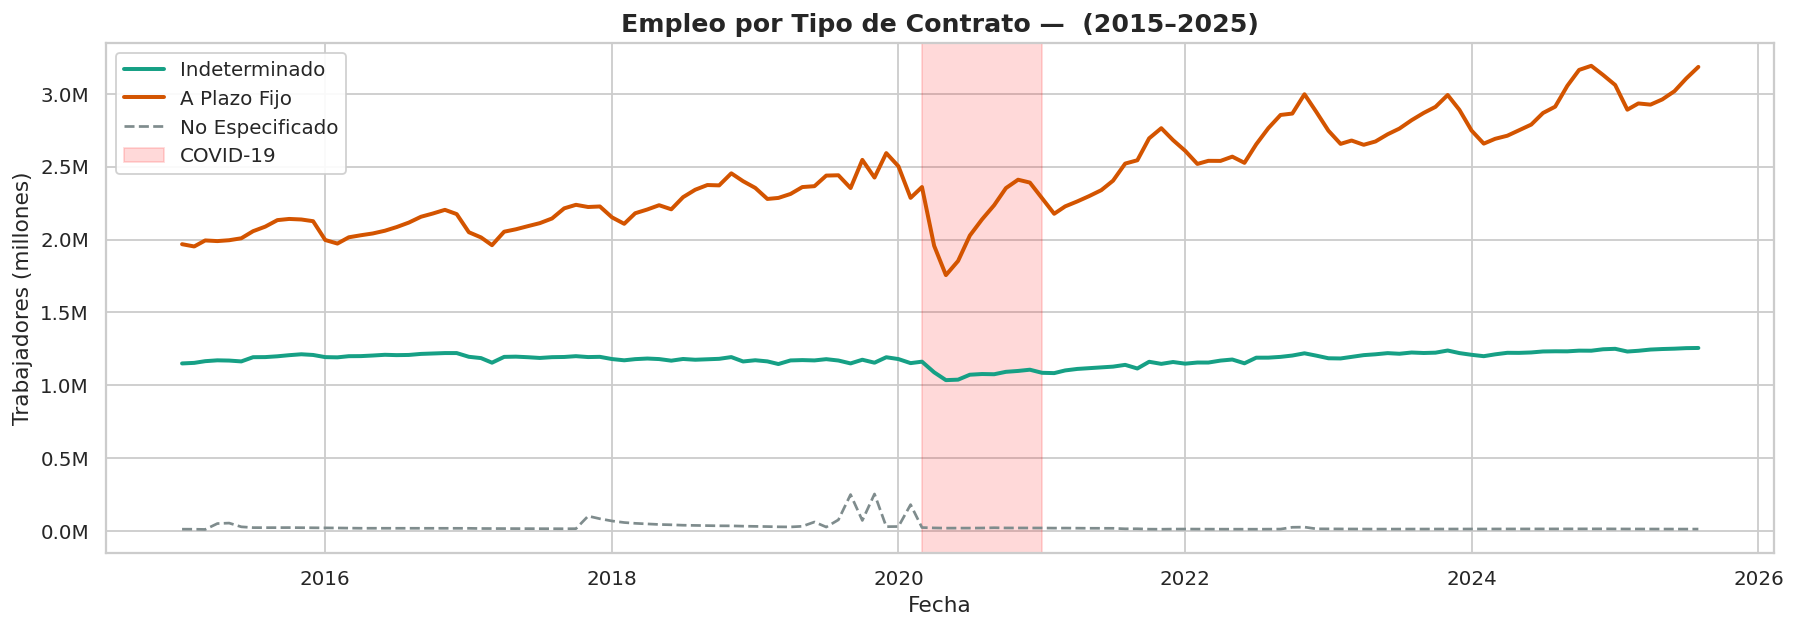

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['fecha'], df['indeterminado']/1e6, label='Indeterminado', color=COLORS['indeterminado'], lw=2.2)
ax.plot(df['fecha'], df['plazo_fijo']/1e6, label='A Plazo Fijo', color=COLORS['plazo_fijo'], lw=2.2)
ax.plot(df['fecha'], df['no_especificado']/1e6, label='No Especificado', color=COLORS['no_esp'], lw=1.5, ls='--')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), alpha=0.15, color='red', label='COVID-19')
ax.set_title('Empleo por Tipo de Contrato —  (2015–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Trabajadores (millones)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

## 4. Participación Porcentual (área apilada)

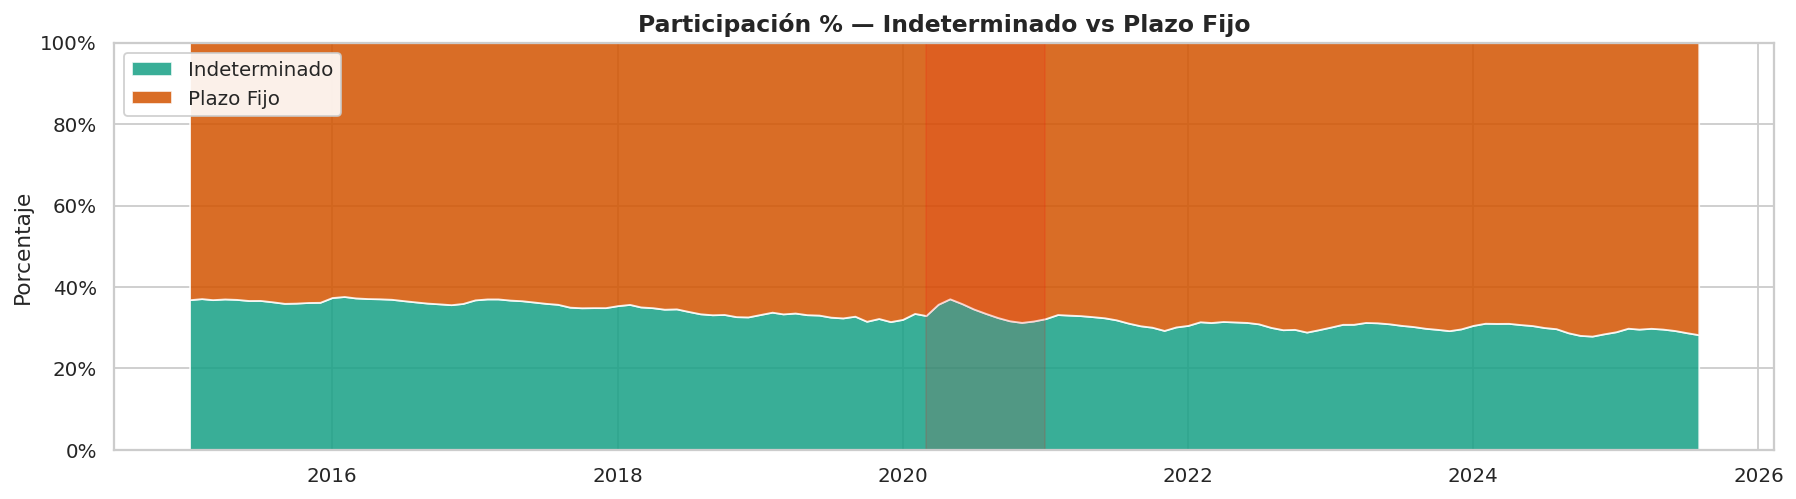

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.stackplot(df2['fecha'], df2['pct_indet'], df2['pct_fijo'],
             labels=['Indeterminado', 'Plazo Fijo'],
             colors=[COLORS['indeterminado'], COLORS['plazo_fijo']], alpha=0.85)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), alpha=0.12, color='red')
ax.set_title('Participación % — Indeterminado vs Plazo Fijo', fontsize=13, fontweight='bold')
ax.set_ylabel('Porcentaje')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

## 5. Ratio Plazo Fijo / Indeterminado (indicador de precariedad laboral)

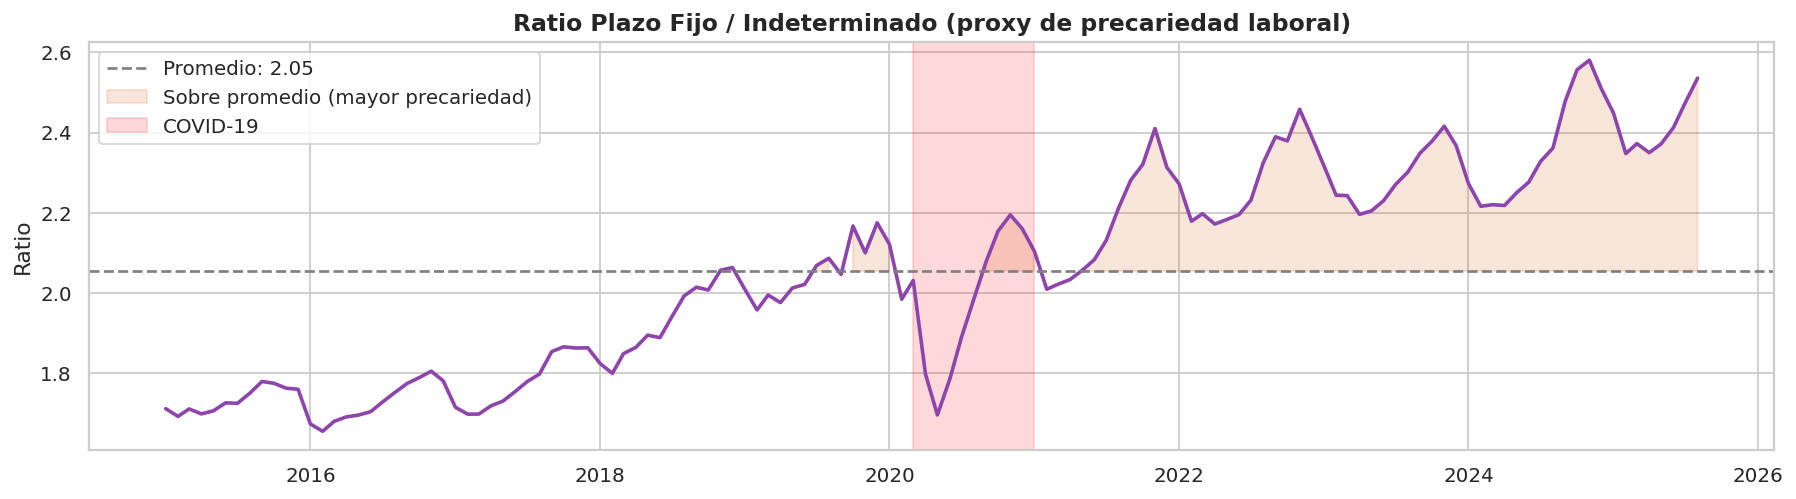

In [7]:
df['ratio_fijo_indet'] = df['plazo_fijo'] / df['indeterminado']
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['fecha'], df['ratio_fijo_indet'], color='#8e44ad', lw=2)
ax.axhline(df['ratio_fijo_indet'].mean(), color='gray', ls='--', lw=1.5,
           label=f'Promedio: {df["ratio_fijo_indet"].mean():.2f}')
ax.fill_between(df['fecha'], df['ratio_fijo_indet'], df['ratio_fijo_indet'].mean(),
                where=df['ratio_fijo_indet'] > df['ratio_fijo_indet'].mean(),
                alpha=0.15, color='#d35400', label='Sobre promedio (mayor precariedad)')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), alpha=0.15, color='red', label='COVID-19')
ax.set_title('Ratio Plazo Fijo / Indeterminado (proxy de precariedad laboral)', fontsize=13, fontweight='bold')
ax.set_ylabel('Ratio')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Promedio Anual por Tipo de Contrato

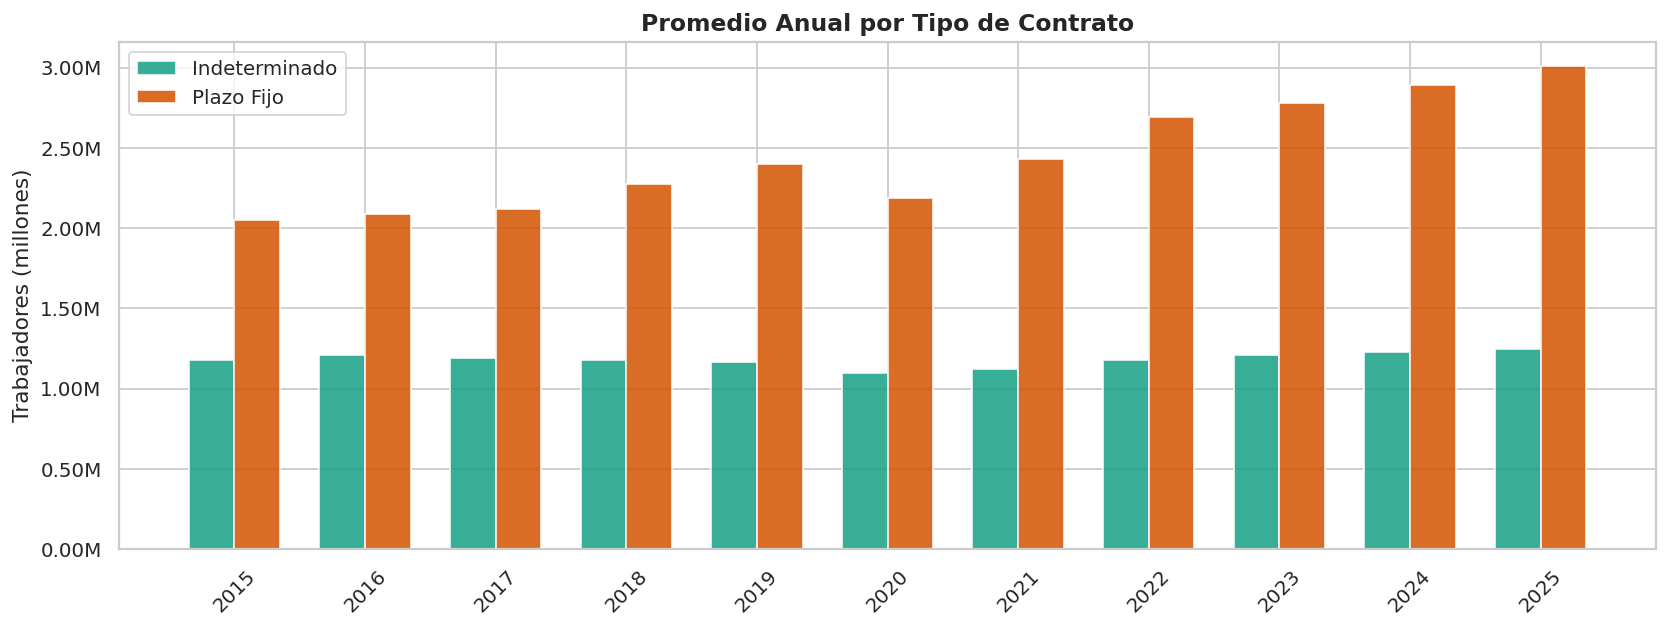

In [8]:
anual = df.groupby('anio')[['indeterminado','plazo_fijo']].mean().reset_index()
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(anual))
w = 0.35
ax.bar(x - w/2, anual['indeterminado']/1e6, w, label='Indeterminado', color=COLORS['indeterminado'], alpha=0.85)
ax.bar(x + w/2, anual['plazo_fijo']/1e6, w, label='Plazo Fijo', color=COLORS['plazo_fijo'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(anual['anio'].astype(int), rotation=45)
ax.set_title('Promedio Anual por Tipo de Contrato', fontsize=13, fontweight='bold')
ax.set_ylabel('Trabajadores (millones)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}M'))
ax.legend()
plt.tight_layout()
plt.show()

## 7. Mapa de Calor — Plazo Fijo

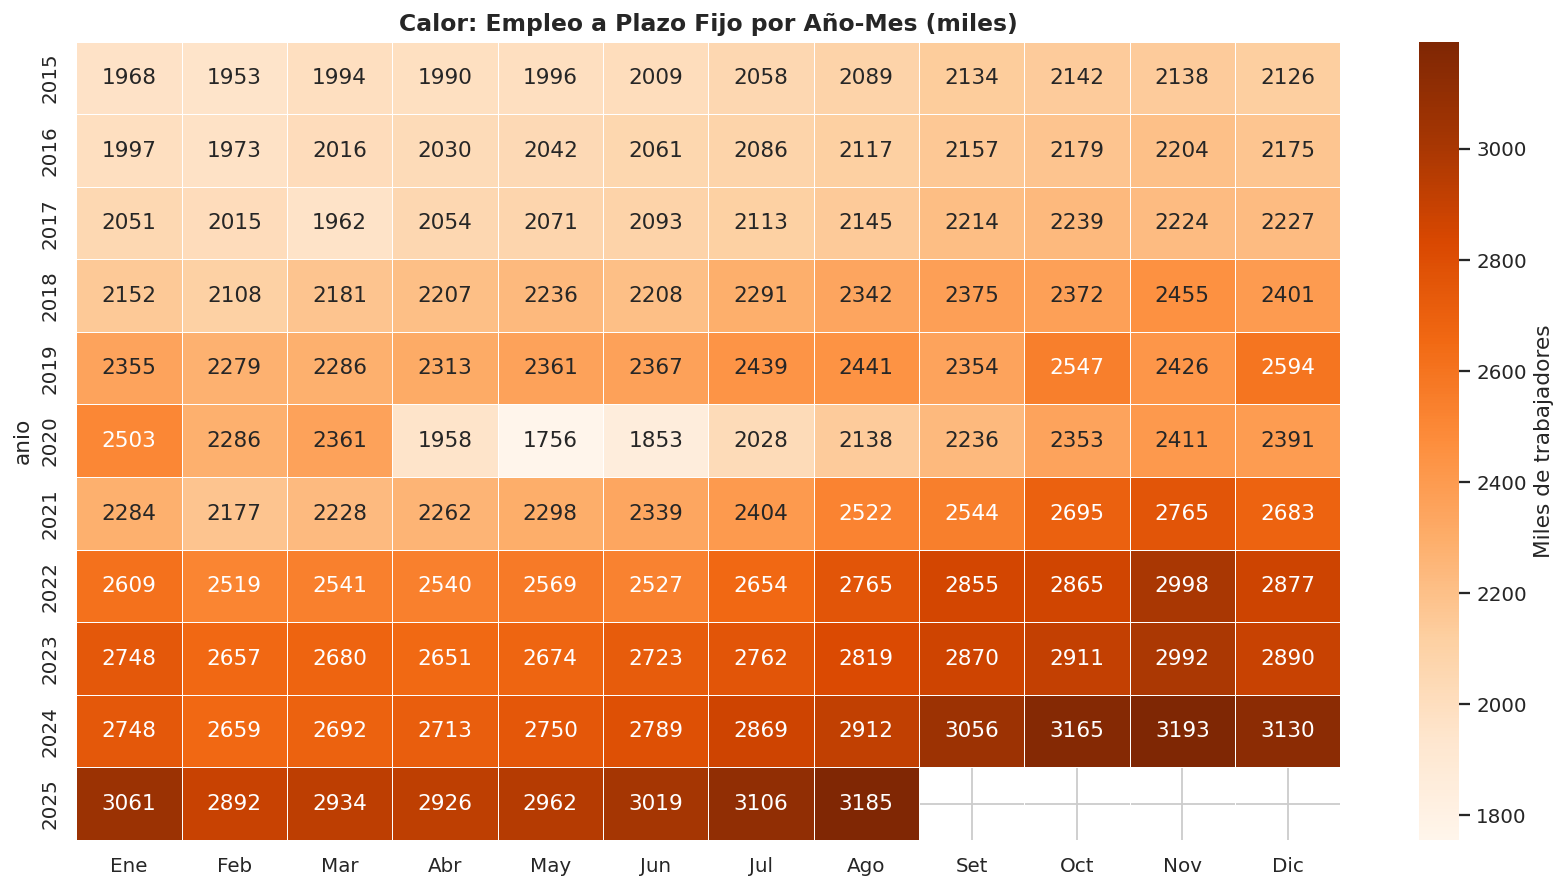

In [9]:
pivot = df.pivot_table(index='anio', columns='mes_num', values='plazo_fijo', aggfunc='mean')
pivot.columns = MESES_ETQ[:len(pivot.columns)]
fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot/1e3, annot=True, fmt='.0f', cmap='Oranges',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Miles de trabajadores'})
ax.set_title('Calor: Empleo a Plazo Fijo por Año-Mes (miles)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Estacionalidad Mensual

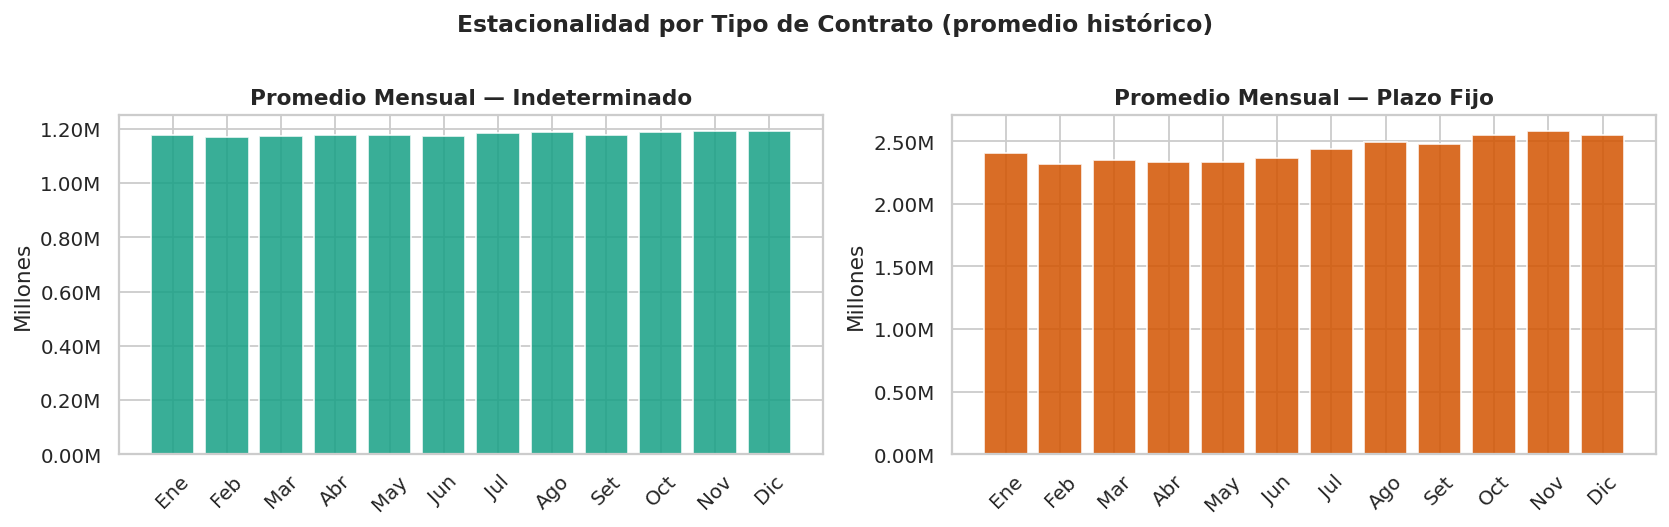

In [10]:
estac = df.groupby('mes_num')[['indeterminado','plazo_fijo']].mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, color, titulo in zip(axes,
    ['indeterminado','plazo_fijo'],
    [COLORS['indeterminado'], COLORS['plazo_fijo']],
    ['Indeterminado','Plazo Fijo']):
    ax.bar(range(1,13), estac[col]/1e6, color=color, alpha=0.85)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(MESES_ETQ, rotation=45)
    ax.set_title(f'Promedio Mensual — {titulo}', fontweight='bold')
    ax.set_ylabel('Millones')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}M'))
plt.suptitle('Estacionalidad por Tipo de Contrato (promedio histórico)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Crecimiento Interanual

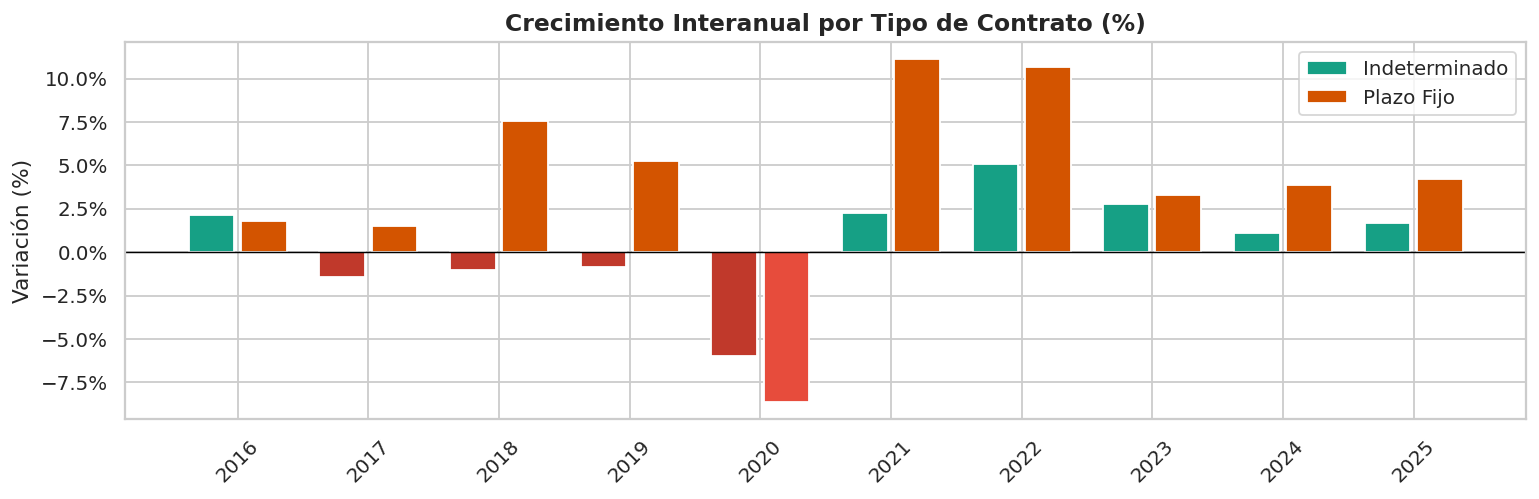

In [11]:
anual_mean = df.groupby('anio')[['indeterminado','plazo_fijo']].mean()
crec = anual_mean.pct_change() * 100
crec = crec.dropna()
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(crec))
ax.bar(x - 0.2, crec['indeterminado'], 0.35, label='Indeterminado',
       color=[COLORS['indeterminado'] if v >= 0 else '#c0392b' for v in crec['indeterminado']])
ax.bar(x + 0.2, crec['plazo_fijo'], 0.35, label='Plazo Fijo',
       color=[COLORS['plazo_fijo'] if v >= 0 else '#e74c3c' for v in crec['plazo_fijo']])
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(crec.index.astype(int), rotation=45)
ax.set_title('Crecimiento Interanual por Tipo de Contrato (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Variación (%)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

## 10. Resumen de Hallazgos

| Métrica | Indeterminado | Plazo Fijo |
|---------|--------------|------------|
| Promedio mensual | ~1,184 K | ~2,288 K |
| Máximo | ~1,257 K (Ago 2025) | ~3,193 K (Nov 2024) |
| Mínimo | ~1,036 K (May 2020) | ~1,756 K (May 2020) |
| Participación promedio | ~34% | ~66% |

**Observaciones clave:**
- El **contrato a plazo fijo** domina con ~66% del empleo privado, lo que indica alta precariedad/temporalidad laboral.
- El **ratio plazo fijo/indeterminado** creció de ~1.6 (2015) a ~2.5 (2025), señalando mayor precarización.
- El **COVID-19** golpeó más al plazo fijo (más fácil de terminar), bajando el ratio temporalmente.
- El **contrato indeterminado** es más estable estacionalmente; el plazo fijo varía más entre meses.